# PBCNet2.0 Prediction Pipeline for proQ Dataset
This notebook is configured for GPU execution and subset processing (10 ligands).

In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import warnings
import torch
import dgl
from rdkit import Chem
from rdkit.Chem import AllChem, BRICS
from rdkit.Chem.rdchem import BondType as BT
from scipy.spatial import distance_matrix
from Bio.PDB import *
from Bio.PDB.PDBIO import Select
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

# Smart path discovery
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, 'proQ')):
    dir_ = os.path.abspath('proQ')
    code_path = os.path.dirname(cwd)
else:
    dir_ = os.path.abspath(os.path.join('case', 'proQ'))
    code_path = cwd

ligand_dir = os.path.join(dir_, 'ligands')
print(f'Project root: {code_path}')
print(f'Data dir: {dir_}')

# GPU Diagnostics
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Found GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU NOT FOUND. Running on CPU instead.')

Project root: D:\PBCNet2.0
Data dir: D:\PBCNet2.0\case\proQ
CUDA available: True
Found GPU: NVIDIA GeForce RTX 3050 Laptop GPU


### 1. Pocket Extraction Logic

In [2]:
def extract(ligand, pdb_path):
    parser = PDBParser(PERMISSIVE=1)
    structure = parser.get_structure("protein", pdb_path)
    
    lp = []
    for l in ligand:
        lp.append(l.GetConformer().GetPositions())
    ligand_positions = np.concatenate(lp)

    class ResidueSelect(Select):
        def accept_residue(self, residue):
            residue_positions = np.array([np.array(list(atom.get_vector())) for atom in residue.get_atoms() if "H" not in atom.get_id()])
            if len(residue_positions.shape) < 2: return 0
            min_dis = np.min(distance_matrix(residue_positions, ligand_positions))
            return 1 if min_dis < 8.0 else 0

    io = PDBIO()
    io.set_structure(structure)
    pocket_path = pdb_path.replace('protein.pdb', 'pocket.pdb')
    io.save(pocket_path, ResidueSelect())

def pocket_extract(sdf_files, protein_file):
    ligands = []
    for a in sdf_files:
        mol = Chem.MolFromMolFile(a)
        if mol: ligands.append(mol)
    extract(ligands, protein_file)
    print("Pocket extracted successfully.")

In [3]:
# Run Pocket Extraction
ligand_dir = os.path.join(dir_, 'ligands')
protein_file = os.path.join(dir_, 'protein.pdb')
sdfs = [os.path.join(ligand_dir, i) for i in os.listdir(ligand_dir) if i.endswith('.sdf')]
for sdf in sdfs:
    pocket_extract([sdf], protein_file)

Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.
Pocket extracted successfully.


### 2. Graph Generation Logic

In [4]:
allowable_features = {
    'possible_chirality_list': ['CHI_UNSPECIFIED', 'CHI_TETRAHEDRAL_CW', 'CHI_TETRAHEDRAL_CCW', 'CHI_OTHER'],
    'possible_degree_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'misc'],
    'possible_numring_list': [0, 1, 2, 3, 4, 5, 6, 'misc'],
    'possible_implicit_valence_list': [0, 1, 2, 3, 4, 5, 6, 'misc'],
    'possible_formal_charge_list': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 'misc'],
    'possible_numH_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 'misc'],
    'possible_number_radical_e_list': [0, 1, 2, 3, 4, 'misc'],
    'possible_hybridization_list': ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'misc'],
    'possible_is_aromatic_list': [False, True],
    'possible_is_in_ring3_list': [False, True],
    'possible_is_in_ring4_list': [False, True],
    'possible_is_in_ring5_list': [False, True],
    'possible_is_in_ring6_list': [False, True],
    'possible_is_in_ring7_list': [False, True],
    'possible_is_in_ring8_list': [False, True]
}
three_to_one = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y', 'SEC': 'C', 'MSE': 'M'}
pro_res_table = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y', 'X']
pro_res_aliphatic_table = ['A', 'I', 'L', 'M', 'V']; pro_res_aromatic_table = ['F', 'W', 'Y']; pro_res_polar_neutral_table = ['C', 'N', 'Q', 'S', 'T']; pro_res_acidic_charged_table = ['D', 'E']; pro_res_basic_charged_table = ['H', 'K', 'R']
bonds = {BT.SINGLE: 0, BT.DOUBLE: 1, BT.TRIPLE: 2, BT.AROMATIC: 3}

def safe_index(l, e): 
    try: return l.index(e)
    except: return len(l)-1

def prop(residue):
    return [1 if residue in pro_res_aliphatic_table else 0, 1 if residue in pro_res_aromatic_table else 0, 1 if residue in pro_res_polar_neutral_table else 0, 1 if residue in pro_res_acidic_charged_table else 0, 1 if residue in pro_res_basic_charged_table else 0, 1]

def res_pocket(p):
    parser = PDBParser(PERMISSIVE=1)
    s = parser.get_structure('a', p)
    atom2res_idx, res_name, count = [], [], -1
    for model in s:
        for chain in model: 
            for residue in chain:
                count += 1; name = residue.get_resname()
                for atom in residue: 
                    if atom.get_fullname()[0] != 'H' and atom.get_fullname()[1] != 'H':
                        atom2res_idx.append(count); res_name.append(name)
    res3 = [three_to_one[i] if i in three_to_one.keys() else 'X' for i in res_name]
    return atom2res_idx, [pro_res_table.index(i) for i in res3], [prop(i) for i in res3]

def lig_atom_featurizer(mol):
    ringinfo = mol.GetRingInfo()
    return [[safe_index(allowable_features['possible_chirality_list'], str(atom.GetChiralTag())), safe_index(allowable_features['possible_degree_list'], atom.GetTotalDegree()), safe_index(allowable_features['possible_formal_charge_list'], atom.GetFormalCharge()), safe_index(allowable_features['possible_numH_list'], atom.GetTotalNumHs()), safe_index(allowable_features['possible_hybridization_list'], str(atom.GetHybridization())), allowable_features['possible_is_aromatic_list'].index(atom.GetIsAromatic()), safe_index(allowable_features['possible_implicit_valence_list'], atom.GetImplicitValence()), safe_index(allowable_features['possible_number_radical_e_list'], atom.GetNumRadicalElectrons()), safe_index(allowable_features['possible_numring_list'], ringinfo.NumAtomRings(idx))] for idx, atom in enumerate(mol.GetAtoms())]

def brics_decomp(mol):
    n_atoms = mol.GetNumAtoms()
    if n_atoms == 1: return [[0]]
    cliques = [[b.GetBeginAtomIdx(), b.GetEndAtomIdx()] for b in mol.GetBonds()]
    res = list(BRICS.FindBRICSBonds(mol))
    if len(res) == 0: return [list(range(n_atoms))]
    for bond in res:
        if [bond[0][0], bond[0][1]] in cliques: cliques.remove([bond[0][0], bond[0][1]])
        else: cliques.remove([bond[0][1], bond[0][0]])
        cliques.append([bond[0][0]]); cliques.append([bond[0][1]])
    for c in range(len(cliques) - 1):
        for k in range(c + 1, len(cliques)):
            if set(cliques[c]) & set(cliques[k]):
                cliques[c] = list(set(cliques[c]) | set(cliques[k])); cliques[k] = []
    return [c for c in cliques if c]

def group_complex(ligand, pocket_dir):
    brics_index = brics_decomp(ligand)
    group_index = [0 for _ in range(len(ligand.GetAtoms()))]
    group_type = [0 for _ in range(len(ligand.GetAtoms()))]
    group_prop = [[0,0,0,0,0,0] for _ in range(len(ligand.GetAtoms()))]
    for i, idx in enumerate(brics_index):
        for idx_ in idx: group_index[idx_] = i
    atom2res_idx, res_type, res_prop = res_pocket(pocket_dir)
    group_index.extend([i+len(brics_index) for i in atom2res_idx])
    group_type.extend([i+1 for i in res_type])
    group_prop.extend(res_prop)
    return torch.tensor(group_index, dtype=torch.float32), torch.tensor(group_type, dtype=torch.float32), torch.tensor(group_prop, dtype=torch.float32)

def bond_featurizer(ligand, pocket, index):
    bond_type = []; num_atoms = len(ligand.GetAtoms())
    for a1, a2 in zip(index[0].tolist(), index[1].tolist()):
        if a1 < num_atoms and a2 < num_atoms: bond = ligand.GetBondBetweenAtoms(int(a1), int(a2)); bond_type.append(bonds[bond.GetBondType()] if bond else 4)
        elif a1 >= num_atoms and a2 >= num_atoms: bond = pocket.GetBondBetweenAtoms(int(a1-num_atoms), int(a2-num_atoms)); bond_type.append(bonds[bond.GetBondType()] if bond else 4)
        else: bond_type.append(4)
    return torch.tensor(bond_type, dtype=torch.float32)

def Graph_Information(ligand_file, pocket_file):
    ligand = Chem.RemoveAllHs(Chem.MolFromMolFile(ligand_file))
    pocket = Chem.RemoveAllHs(Chem.MolFromPDBFile(pocket_file))
    if not pocket or not ligand: raise ValueError("Could not load pocket or ligand. Check file sanity.")
    G = dgl.heterograph({('atom', 'int', 'atom'): ([], []), ('atom', 'ind', 'atom'): ([], [])})
    l_at, p_at = np.array([i.GetAtomicNum() for i in ligand.GetAtoms()]), np.array([i.GetAtomicNum() for i in pocket.GetAtoms()])
    graph_x = torch.tensor(np.concatenate([l_at, p_at]))
    G.add_nodes(len(l_at) + len(p_at))
    coor_l, coor_p = ligand.GetConformer().GetPositions(), pocket.GetConformer().GetPositions()
    pos = torch.tensor(np.concatenate([coor_l, coor_p]), dtype=torch.float32)
    for i in range(len(coor_l)):
        for j in range(i + 1, len(coor_l)):
            if 0 < np.linalg.norm(coor_l[i] - coor_l[j]) <= 5: G.add_edges([i, j], [j, i], etype='int')
    for b in pocket.GetBonds():
        u, v = b.GetBeginAtomIdx() + len(coor_l), b.GetEndAtomIdx() + len(coor_l); G.add_edges([u, v], [v, u], etype='int')
    for i in range(len(coor_l)):
        for j in range(len(coor_p)):
            if 0 < np.linalg.norm(coor_l[i] - coor_p[j]) <= 5: G.add_edges([i, len(coor_l) + j], [len(coor_l) + j, i], etype='int')
    conn_p = set(int(j) for i in range(len(coor_l)) for j in G.successors(i, etype='int') if j >= len(coor_l))
    for i in conn_p:
        for j in range(len(coor_p)):
            if i != len(coor_l)+j and 0 < np.linalg.norm(coor_p[i-len(coor_l)] - coor_p[j]) <= 3 and not G.has_edges_between(i, len(coor_l)+j, etype='int'): G.add_edges([i, len(coor_l)+j], [len(coor_l)+j, i], etype='int')
    index, g_type, g_prop = group_complex(ligand, pocket_file)
    G.nodes['atom'].data.update({'x': graph_x, 'pos': pos, 'type': torch.tensor(np.concatenate([[1]*len(l_at), [0]*len(p_at)])), 'atom_scalar': torch.tensor(np.concatenate([lig_atom_featurizer(ligand), lig_atom_featurizer(pocket)]), dtype=torch.float32), 'res_idx': index, 'res_type': g_type, 'res_prop': g_prop})
    G.edges['int'].data['bond_scalar'] = bond_featurizer(ligand, pocket, G.edges(etype='int'))
    G.edges['ind'].data['bond_scalar'] = bond_featurizer(ligand, pocket, G.edges(etype='ind'))
    return G

def graph_save(lig_f, pock_f, save_f):
    print("hello")
    if not os.path.exists(lig_f) or not os.path.exists(pock_f): return
    with open(save_f, 'wb') as f: pickle.dump(Graph_Information(lig_f, pock_f), f)

In [5]:
# Run Graph Generation
pocket_f = os.path.join(dir_, 'pocket.pdb')
data_list = [[os.path.join(ligand_dir, i), pocket_f, os.path.join(ligand_dir, i.replace('.sdf', '.pkl'))] for i in os.listdir(ligand_dir) if i.endswith('.sdf')]
for lig_f, pock_f, save_f in data_list:
    graph_save(lig_f, pock_f, save_f)
print("Graphs generated successfully.")

hello
hello
hello
hello
hello
hello
hello
hello
hello
hello
Graphs generated successfully.


### 3. CSV Input Preparation

In [6]:
def input_G(pickles, lab):
    data_list = []
    for i, pkl1 in enumerate(pickles):
        if i == len(pickles) - 1: break
        N1, D1, L1 = [], [], []
        N2, D2, L2 = [], [], []
        L = []
        for j, pkl2 in enumerate(pickles):
            N1.append(os.path.basename(pkl1)); D1.append(pkl1); L1.append(lab[i])
            N2.append(os.path.basename(pkl2)); D2.append(pkl2); L2.append(lab[j])
            L.append(lab[i] - lab[j])
        data_list.append(pd.DataFrame({'lig1': N1, 'lig2': N2, 'Label': L, 'Label1': L, 'Label2': L, 'dir_1': D1, 'dir_2': D2}))
    if not data_list:
        print('No data list available for concatenation.')
    else:
        pd.concat(data_list).to_csv(os.path.join(dir_, 'predict.csv'), index=0)

pkls = [os.path.join(ligand_dir, i) for i in os.listdir(ligand_dir) if i.endswith('.pkl')]
ic50 = [7.47, 8.52, 8.3, 7.77, 7.6, 8.1, 7.5, 8.0, 7.8, 8.2]
input_G(pkls, ic50)
print("predict.csv created.")

predict.csv created.


### 4. Model Prediction (GPU)

In [7]:
import sys
sys.path.append(os.path.join(code_path, 'model_code'))
from Dataloader.dataloader import LeadOptDataset, collate_fn
from predict.predict import predict as model_predict

def test_gpu(model, device, csv_path, batch_size):
    model.to(device)
    dataset = LeadOptDataset(csv_path)
    loader = DataLoader(dataset, collate_fn=collate_fn, batch_size=batch_size, shuffle=False)
    *_, valid_prediction, _, _, _, _ = model_predict(model, loader, device)
    return valid_prediction

model_file = os.path.join(code_path, 'PBCNet2.pth')
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Prediction running on: {device}')

model = torch.load(model_file, map_location=torch.device(device), weights_only=False)

csv_path = os.path.join(dir_, 'predict.csv')
pre = test_gpu(model, device, csv_path, 8)

df = pd.read_csv(csv_path)
df['pre'] = pre
df.to_csv(csv_path, index=0)
print("Prediction complete. Results saved in predict.csv")

D:\PBCNet2.0\model_code\Dataloader
Prediction running on: cuda:0
Prediction complete. Results saved in predict.csv


### 5. Final Results View

In [8]:
pd.read_csv(os.path.join(dir_, 'predict.csv')).head(10)

,lig1,lig2,Label,Label1,Label2,dir_1,dir_2,pre
0,ligand_0.pkl,ligand_0.pkl,0.00,0.00,0.00,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,-0.079732
1,ligand_0.pkl,ligand_1.pkl,-1.05,-1.05,-1.05,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_1.pkl,0.812519
2,ligand_0.pkl,ligand_2.pkl,-0.83,-0.83,-0.83,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_2.pkl,0.404361
3,ligand_0.pkl,ligand_3.pkl,-0.30,-0.30,-0.30,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_3.pkl,0.419845
4,ligand_0.pkl,ligand_4.pkl,-0.13,-0.13,-0.13,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_4.pkl,0.726432
5,ligand_0.pkl,ligand_5.pkl,-0.63,-0.63,-0.63,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_5.pkl,0.548151
6,ligand_0.pkl,ligand_6.pkl,-0.03,-0.03,-0.03,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_6.pkl,0.752485
7,ligand_0.pkl,ligand_7.pkl,-0.53,-0.53,-0.53,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_7.pkl,0.711395
8,ligand_0.pkl,ligand_8.pkl,-0.33,-0.33,-0.33,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_8.pkl,0.924541
9,ligand_0.pkl,ligand_9.pkl,-0.73,-0.73,-0.73,D:\PBCNet2.0\case\proQ\ligands\ligand_0.pkl,D:\PBCNet2.0\case\proQ\ligands\ligand_9.pkl,0.493736


### 6. Visualization and Metrics

In [ ]:
import scipy.stats as stats
from sklearn.metrics import mean_squared_error

def S(X, Y): return stats.spearmanr(X, Y)[0]
def R(X, Y): return stats.pearsonr(X, Y)[0]
def RMSE(X, Y): return mean_squared_error(X, Y) ** 0.5

csv_path = os.path.join(dir_, 'predict.csv')
df = pd.read_csv(csv_path)

print(f"Spearman correlation: {S(df['Label1'], df['pre']):.4f}")
print(f"Pearson correlation: {R(df['Label1'], df['pre']):.4f}")
print(f"RMSE: {RMSE(df['Label1'], df['pre']):.4f}")

Spearman correlation: 0.0591
Pearson correlation: 0.0741
RMSE: 0.7634


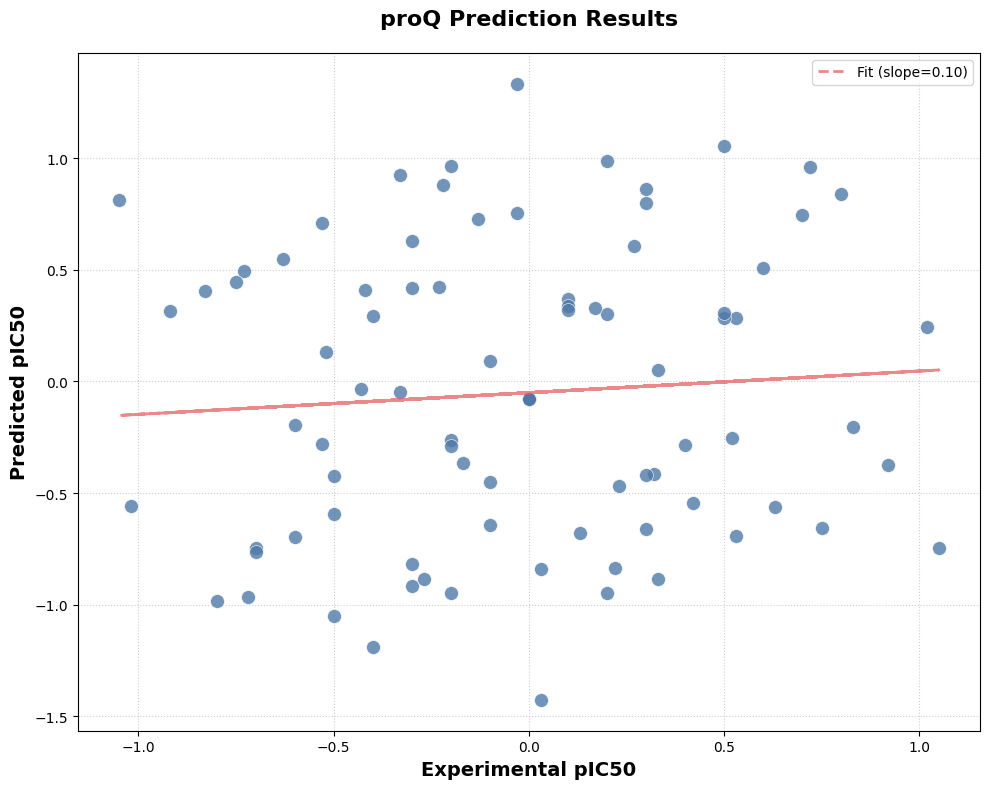

In [10]:
import matplotlib.pyplot as plt

def plt_scatter(x, y, title='proQ Prediction Results'):
    fig, axs = plt.subplots(1, 1, figsize=(10, 8))
    # Use a premium color palette
    axs.scatter(x, y, alpha=0.8, s=100, c="#4E79A7", edgecolors='white', linewidth=0.5, zorder=2)
    
    # Regression line
    parameter = np.polyfit(x, y, 1)
    y_pred = parameter[0] * np.array(x) + parameter[1]
    axs.plot(x, y_pred, ls="--", linewidth=2, alpha=0.7, c='#E15759', label=f'Fit (slope={parameter[0]:.2f})')
    
    axs.set_ylabel("Predicted pIC50", fontsize=14, fontweight='bold')
    axs.set_xlabel("Experimental pIC50", fontsize=14, fontweight='bold')
    axs.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    axs.grid(True, linestyle=':', alpha=0.6)
    axs.legend()
    plt.style.use('ggplot')
    plt.tight_layout()
    plt.show()

plt_scatter(df['Label1'], df['pre'])